### Create the MIST Geometry Using Techniques from `planning.ipynb`

In [175]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle

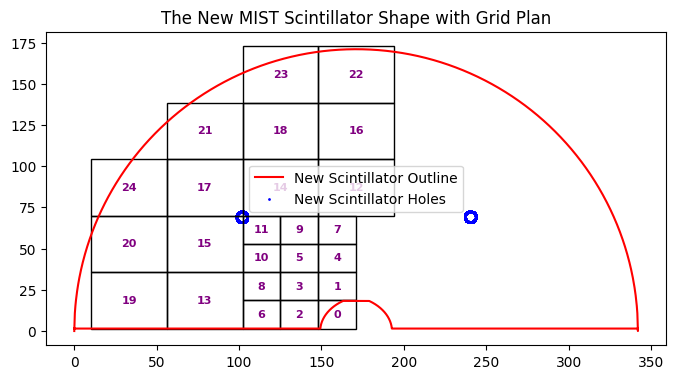

In [176]:
line1 = [np.linspace(0,171-21.75,1000),np.full(1000,1.5)]
xi,yi = -np.sqrt(21.75**2-1.5**2), 1.5
xf,yf = 171-15.69/2,18.3
line2 = [np.linspace(171+xi,xf,1000),np.array([np.sqrt(21.75**2-x**2) for x in np.linspace(xi,-np.sqrt(21.75**2-18.3**2),1000)])]
line3 = [np.linspace(xf,171+15.69/2,1000),np.full(1000,yf)]

xf,yf = np.sqrt(21.75**2-1.5**2), 1.5
xi,yi = 171+15.69/2,18.3
line4 = [np.linspace(xi,171+xf,1000),np.array([np.sqrt(21.75**2-x**2) for x in np.linspace(np.sqrt(21.75**2-18.3**2),xf,1000)])]
line5 = [np.linspace(171+21.75,342,1000),np.full(1000,1.5)]

line6 = [np.linspace(0,342,1000),np.array([np.sqrt(171**2-x**2) for x in np.linspace(-171,171,1000)])]

new_scint = np.concatenate((line1, line2, line3, line4, line5, np.flip(line6, axis=1)), axis=1)

r = 3.3
circ = np.transpose(np.array([r * np.array([np.cos(theta), np.sin(theta)]) for theta in np.linspace(0, 2*np.pi, 1000)]))
line7 = circ + np.transpose(np.full((1000, 2), [171-69.3, 69.3]))
line8 = circ + np.transpose(np.full((1000, 2), [171+69.3, 69.3]))

holes = np.concatenate((line7, line8), axis=1)


fig, ax = plt.subplots(figsize=(8, 8))
patches = []

width = 22.96
height = 17.14
centre_range = 4

# Base large dimensions
width *= 2
height *= 2

rows = round(171/height)
cols = round(342/width)
centring_correction = (cols*width - 342)/2

# --- 1. POPULATE PATCHES WITH CORRECT COORDINATE MATH ---
for row in range(rows):
    for col in range(cols):
        # Determine if we are in the middle-third horizontally and bottom-third vertically
        if (col > cols/centre_range and col < (round(centre_range/2))*cols/centre_range) and (row < rows/centre_range):
            
            # Base offsets for this specific grid cell
            x_base = col * width - centring_correction
            y_base = row * height + 1.5
            
            w_sub = width / 2
            h_sub = height / 2
            
            # Bottom-left sub-rectangle
            patches.append(Rectangle((x_base, y_base), w_sub, h_sub))
            # Bottom-right sub-rectangle
            patches.append(Rectangle((x_base + w_sub, y_base), w_sub, h_sub))
            # Top-left sub-rectangle
            patches.append(Rectangle((x_base, y_base + h_sub), w_sub, h_sub))
            # Top-right sub-rectangle
            patches.append(Rectangle((x_base + w_sub, y_base + h_sub), w_sub, h_sub))
        else:
            patches.append(Rectangle((col * width - centring_correction, row * height + 1.5), width, height))

# --- 2. FILTER AND TRACK DYNAMIC DIMENSIONS ---
target_center, target_range = np.array([171, 1.5]), 170
new_box_data = []

for patch in patches:
    # Safely extract the custom width and height of THIS specific rectangle
    w = patch.get_width()
    h = patch.get_height()
    
    x, y = patch.get_xy()
    x_c = x + w / 2
    y_c = y + h / 2
    x_shift = x + w

    # Out of circular boundary check
    if np.linalg.norm(np.array([x_c, y_c]) - target_center) > target_range:
        continue
    # Bottom cutout check
    if y == 1.5 and (x > 171-21.75 and x < 171+21.75) and (x_shift > 171-21.75 and x_shift < 171+21.75):
        continue
    # Right-hand side removal constraint
    if x_c > 171:
        continue

    # Calculate distance for sorting
    distance = np.linalg.norm(np.array([x_c, y_c]) - target_center)
    
    new_box_data.append({
        'xy': (x, y),
        'w': w,
        'h': h,
        'centre': (x_c, y_c),
        'distance': distance
    })

# Sort by distance from target center
new_box_data.sort(key=lambda item: item['distance'])

# --- 3. PLOT AND LABEL ---
plt.title("The New MIST Scintillator Shape with Grid Plan")
plt.plot(new_scint[0], new_scint[1], label="New Scintillator Outline", color='red')
plt.scatter(holes[0], holes[1], label="New Scintillator Holes", s=1, color='blue')

# Redraw the filtered patches using their unique stored sizes
for box_id, data in enumerate(new_box_data):
    x, y = data['xy']
    w, h = data['w'],data['h']
    x_c, y_c = data['centre']
    
    # Draw the rectangle with its exact individual size
    rect = Rectangle((x, y), w, h, facecolor='none', edgecolor='black')
    ax.add_patch(rect)
    
    # Place text exactly at the calculated center
    ax.text(x_c, y_c, str(box_id), color='purple', fontsize=8,
            ha='center', va='center', weight='bold')

ax = plt.gca()
ax.set_aspect('equal')
plt.legend()
plt.show()

(999, 2) (1, 2)
-10.280000000000001
20
Box 0 has 100.00% overlap with the scintillator
Box 1 has 100.00% overlap with the scintillator
Box 2 has 100.00% overlap with the scintillator
Box 3 has 100.00% overlap with the scintillator
Box 4 has 100.00% overlap with the scintillator
Box 5 has 100.00% overlap with the scintillator
Box 6 has 100.00% overlap with the scintillator
Box 7 has 100.00% overlap with the scintillator
Box 8 has 100.00% overlap with the scintillator
Box 9 has 100.00% overlap with the scintillator
Box 10 has 100.00% overlap with the scintillator
Box 11 has 100.00% overlap with the scintillator
Box 12 has 100.00% overlap with the scintillator
Box 13 has 100.00% overlap with the scintillator
Box 14 has 100.00% overlap with the scintillator
Box 15 has 100.00% overlap with the scintillator
Box 16 has 100.00% overlap with the scintillator
Box 17 has 100.00% overlap with the scintillator
Box 18 has 100.00% overlap with the scintillator
Box 19 has 100.00% overlap with the scin

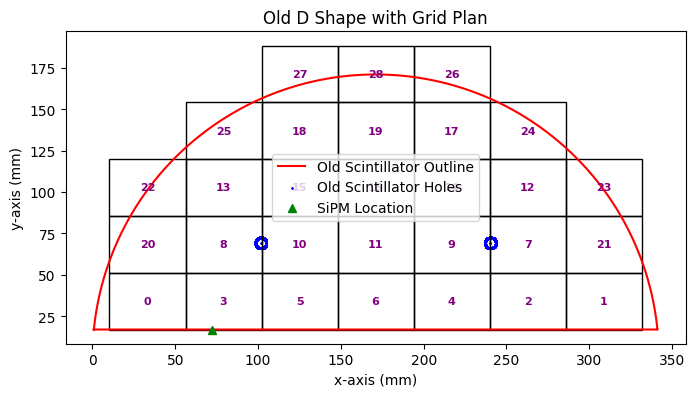

Number of boxes: 29


In [177]:
from shapely.geometry import Polygon, box

def circle(radius):
   circ = np.array([radius * np.array([np.cos(theta), np.sin(theta)]) for theta in np.linspace(0, 2*np.pi, 999)])
   centre = np.array([np.array([0,0])])
   print(circ.shape,centre.shape)
   return np.transpose(np.concatenate((circ,centre),axis=0))

R = 171
h = 17

xi,xf = -np.sqrt(R**2-h**2) + R, np.sqrt(R**2-h**2) + R, 
X_centre = np.sqrt(R**2-h**2)+xi

line1 = [np.linspace(xi,xf,1000),np.array([np.sqrt(171**2-x**2) for x in np.linspace(xi-R,xf-R,1000)])]
line2 = [np.linspace(xf,xi,1000),np.full(1000,h)]

old_scint = np.concatenate((line1, line2), axis=1)

circ = circle(3.3)
line7 = circ + np.transpose(np.full((1000, 2), [171-69.3, 69.3]))
line8 = circ + np.transpose(np.full((1000, 2), [171+69.3, 69.3]))

holes = np.concatenate((line7, line8), axis=1)

old_scint_shape = Polygon(shell=np.transpose(old_scint), holes=[np.transpose(line7), np.transpose(line8)])
old_scint_shape_wout_holes = Polygon(shell=np.transpose(old_scint))

SiPM_loc = [65+7,h]

fig, ax = plt.subplots(figsize=(8, 8))
patches = []

tolerance = 0.9
scale_factor = 0.75

width = 22.96
height = 17.14
centre_range = 4

# Base large dimensions
width *= 2
height *= 2

rows = round(R/height)
cols = round(2*R/width)
centring_correction = (cols*width - X_centre*2)/2
print(centring_correction)

# --- 1. POPULATE PATCHES WITH CORRECT COORDINATE MATH ---
for row in range(rows):
    for col in range(cols):
        x,y = col * width - centring_correction, row * height + h
        x_c = x + width / 2
        y_c = y + height / 2
        patches.append(Rectangle((x,y), width, height))

# --- 2. FILTER AND TRACK DYNAMIC DIMENSIONS ---
target_center, target_range = np.array([R, 0]), R
old_box_data = []

for patch in patches:
    # Safely extract the custom width and height of THIS specific rectangle
    w = patch.get_width()
    h = patch.get_height()
    
    x, y = patch.get_xy()
    x_c = x + w / 2
    y_c = y + h / 2
    x_shift = x + w
    y_shift = y + h

    # Out of circular boundary check
    if np.linalg.norm(np.array([x, y_shift]) - target_center) > target_range or np.linalg.norm(np.array([x_shift, y_shift]) - target_center) > target_range:
        continue
    # Bottom cutout check
    if y == 1.5 and (x > 171-21.75 and x < 171+21.75) and (x_shift > 171-21.75 and x_shift < 171+21.75):
        continue
    # Right-hand side removal constraint
    # if x_c > 171:
    #     continue

    # Calculate distance for sorting
    distance = np.linalg.norm(np.array([x_c, y_c]) - target_center)
    overlap = old_scint_shape_wout_holes.intersection(box(x,y,x+w,y+h))
    # print(f'Overlapping area: {overlap.area} => {overlap.area/w/h*100:.2f}% overlap')
    
    old_box_data.append({
        'xy': (x, y),
        'w': w,
        'h': h,
        'centre': (x_c, y_c),
        'distance': distance,
        'weighting': overlap.area/w/h # Proportion of overlapping area of box
    })

print(len(old_box_data))

# Sort by distance from target center
# box_data.sort(key=lambda item: item['distance'], reverse=True)
old_box_data.sort(key=lambda item: (item['xy'][1], -item['distance']))

# Add in additional, custom boxes (grid expansion requested by Carsten)
for below in [0,1,20,21,12,13,17,18,19]:
    x,y = old_box_data[below]['xy']
    y += h # Move up one box
    distance = np.linalg.norm(np.array([x+w/2, y+h/2]) - target_center)
    overlap = old_scint_shape_wout_holes.intersection(box(x,y,x+w,y+h))
    old_box_data.append({
        'xy': (x, y),
        'w': w,
        'h': h,
        'centre': (x+w/2, y+h/2),
        'distance': distance,
        'weighting': overlap.area/w/h # Proportion of overlapping area of box
    })

# Make scaled down model
tc_col = target_center.reshape(2, 1)
scaled_scint = tc_col + scale_factor * (old_scint - tc_col)
scaled_holes = tc_col + scale_factor * (holes - tc_col)

# --- 3. PLOT AND LABEL ---
plt.title("Old D Shape with Grid Plan")
plt.plot(old_scint[0], old_scint[1], label="Old Scintillator Outline", color='red')
plt.scatter(holes[0], holes[1], label="Old Scintillator Holes", s=1, color='blue')

# Redraw the filtered patches using their unique stored sizes
for box_id, data in enumerate(old_box_data):
    x, y = data['xy']
    w, h = data['w'],data['h']
    x_c, y_c = data['centre']
    # print(f"Box {box_id} has centre at ({x_c}, {y_c})")
    print(f'Box {box_id} has {data['weighting']*100:.2f}% overlap with the scintillator')
    
    # Draw the rectangle with its exact individual size
    rect = Rectangle((x, y), w, h, facecolor='none', edgecolor='black')
    ax.add_patch(rect)
    
    # Place text exactly at the calculated center
    ax.text(x_c, y_c, str(box_id), color='purple', fontsize=8,
            ha='center', va='center', weight='bold')

ax = plt.gca()
ax.set_aspect('equal')
plt.plot(SiPM_loc[0],SiPM_loc[1],label='SiPM Location',color='green',linestyle='',marker='^')
plt.legend()
plt.xlabel('x-axis (mm)')
plt.ylabel('y-axis (mm)')
# plt.ylim(0,342)
plt.show()

print(f"Number of boxes: {len(old_box_data)}")

(999, 2) (1, 2)
20


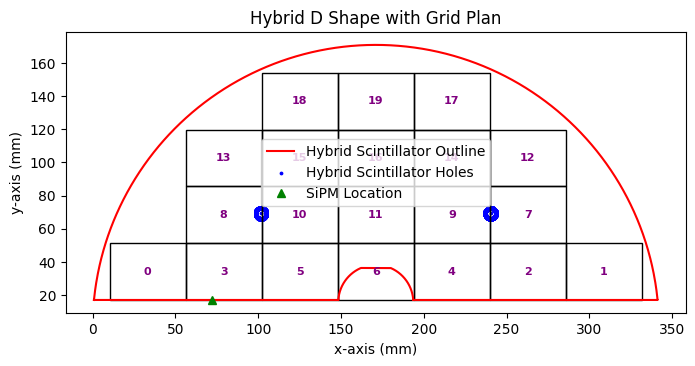

Number of boxes: 20


In [178]:
def circle(radius):
   circ = np.array([radius * np.array([np.cos(theta), np.sin(theta)]) for theta in np.linspace(0, 2*np.pi, 999)])
   centre = np.array([np.array([0,0])])
   print(circ.shape,centre.shape)
   return np.transpose(np.concatenate((circ,centre),axis=0))

circ = circle(3.3)
line7 = circ + np.transpose(np.full((1000, 2), [171-69.3, 69.3]))
line8 = circ + np.transpose(np.full((1000, 2), [171+69.3, 69.3]))

holes = np.concatenate((line7, line8), axis=1)


45.2, 19.64, 17.1
r_0 = 21.75
h_0 = 18.4
h_m = 19.64
l_0 = 15.69
l_min, l_max = 16.94, 19.64
w_0 = 2*(np.sqrt(r_0**2-1.5**2))
w_m = 45.2
r_0 = 21.75

delta = 0.036*25.4
w = w_0+2*delta
h = h_0+delta
r = r_0+delta
l = 2*np.sqrt(r**2-h**2)

R = 171
H = 17
d = 1.5
SiPM_loc = [65+7,H]

xi,xf = -np.sqrt(R**2-H**2) + R, np.sqrt(R**2-H**2) + R,
W = xf-xi
c = W/2+xi
line1 = [np.linspace(xi,c-w/2,1000),np.full(1000,H)]
line2 = [np.linspace(c+w/2,xf,1000),np.full(1000,H)]

line3 = [np.linspace(xf,xi,1000),np.array([np.sqrt(R**2-x**2) for x in np.linspace(xf-R,xi-R,1000)])]

start,stop = np.sqrt(r**2-d**2), np.sqrt(r**2-(h+d)**2),
line4 = [np.linspace(c-start,c-stop,1000),np.array([np.sqrt(r**2-x**2)+H-d for x in np.linspace(start,stop,1000)])]
line5 = [np.linspace(c+start,c+stop,1000)[::-1],np.array([np.sqrt(r**2-x**2)+H-d for x in np.linspace(start,stop,1000)])[::-1]]
line6 = [np.linspace(c-stop,c+stop,1000),np.full(1000,H+h)]


hybrid_scint = np.concatenate((line1, line4, line6, line5, line2, line3), axis=1)

fig, ax = plt.subplots(figsize=(8, 8))
patches = []

R,h = 171, 17
xi,xf = -np.sqrt(R**2-h**2) + R, np.sqrt(R**2-h**2) + R, 
X_centre = np.sqrt(R**2-h**2)+xi

tolerance = 0.9
scale_factor = 0.75

width = 22.96
height = 17.14
centre_range = 4

# Base large dimensions
width *= 2
height *= 2

rows = round(R/height)
cols = round(2*R/width)
centring_correction = (cols*width - X_centre*2)/2

# --- 1. POPULATE PATCHES WITH CORRECT COORDINATE MATH ---
for row in range(rows):
    for col in range(cols):
        x,y = col * width - centring_correction, row * height + h
        x_c = x + width / 2
        y_c = y + height / 2
        dist = np.linalg.norm([x_c,y_c] - target_center)
        patches.append(Rectangle((x,y), width, height))

# --- 2. FILTER AND TRACK DYNAMIC DIMENSIONS ---
target_center, target_range = np.array([R, 0]), R
hybrid_box_data = []

for patch in patches:
    # Safely extract the custom width and height of THIS specific rectangle
    w = patch.get_width()
    h = patch.get_height()
    
    x, y = patch.get_xy()
    x_c = x + w / 2
    y_c = y + h / 2
    x_shift = x + w
    y_shift = y + h

    # Out of circular boundary check
    if np.linalg.norm(np.array([x, y_shift]) - target_center) > target_range or np.linalg.norm(np.array([x_shift, y_shift]) - target_center) > target_range:
        continue
    # Bottom cutout check
    if y == 1.5 and (x > 171-21.75 and x < 171+21.75) and (x_shift > 171-21.75 and x_shift < 171+21.75):
        continue
    # Right-hand side removal constraint
    # if x_c > 171:
    #     continue

    # Calculate distance for sorting
    distance = np.linalg.norm(np.array([x_c, y_c]) - target_center)
    
    hybrid_box_data.append({
        'xy': (x, y),
        'w': w,
        'h': h,
        'centre': (x_c, y_c),
        'distance': distance
    })

print(len(hybrid_box_data))

# Sort by distance from target center
# box_data.sort(key=lambda item: item['distance'], reverse=True)
hybrid_box_data.sort(key=lambda item: (item['xy'][1], -item['distance']))

# Make scaled down model
tc_col = target_center.reshape(2, 1)
scaled_scint = tc_col + scale_factor * (hybrid_scint - tc_col)
scaled_holes = tc_col + scale_factor * (holes - tc_col)

# --- 3. PLOT AND LABEL ---
plt.title("Hybrid D Shape with Grid Plan")
plt.plot(hybrid_scint[0], hybrid_scint[1], label="Hybrid Scintillator Outline", color='red')
plt.scatter(holes[0], holes[1], label="Hybrid Scintillator Holes", s=3, color='blue')

# Redraw the filtered patches using their unique stored sizes
for box_id, data in enumerate(hybrid_box_data):
    x, y = data['xy']
    w, h = data['w'],data['h']
    x_c, y_c = data['centre']
    
    # Draw the rectangle with its exact individual size
    rect = Rectangle((x, y), w, h, facecolor='none', edgecolor='black')
    ax.add_patch(rect)
    
    # Place text exactly at the calculated center
    ax.text(x_c, y_c, str(box_id), color='purple', fontsize=8,
            ha='center', va='center', weight='bold')

ax = plt.gca()
ax.set_aspect('equal')
plt.plot(SiPM_loc[0],SiPM_loc[1],label='SiPM Location',color='green',linestyle='',marker='^')
plt.legend()
plt.xlabel('x-axis (mm)')
plt.ylabel('y-axis (mm)')
# plt.ylim(0,342)
plt.show()

print(f"Number of boxes: {len(hybrid_box_data)}")

### Scintillator Placements:

In [179]:
id = 0

print("          | Horizontal Distance |   Vertical distance   |  Size of  |          |  Time  |")
print("    ID    | from Left Edge (cm) | from Bottom Edge (cm) | Rectangle | Rotation | Needed |")
print("----------+---------------------+-----------------------+-----------+----------+--------|")
print(f" baseline |                {SiPM_loc[0]-width/2:.1f} |                   0.0 |     Large |       0° |   100% |")

for box in old_box_data:
    x, y = box['xy']
    w, h = box['w'], box['h']
    rot = False
    if w == width:
        size='Large'
    elif w == width/2:
        size='Small'
    elif w == height/2:
        size='Small'
        rot=True
    else:
        size='Unknown'
    print(f" {id:8d} | {x/10:19.1f} | {(y-17)/10:21.1f} | {size:>9} | {"90°" if rot else "0°":>8} | {1/box['weighting']*100:>6.1f}% |")
    id+=1

          | Horizontal Distance |   Vertical distance   |  Size of  |          |  Time  |
    ID    | from Left Edge (cm) | from Bottom Edge (cm) | Rectangle | Rotation | Needed |
----------+---------------------+-----------------------+-----------+----------+--------|
 baseline |                49.0 |                   0.0 |     Large |       0° |   100% |
        0 |                 1.0 |                   0.0 |     Large |       0° |  100.0% |
        1 |                28.6 |                   0.0 |     Large |       0° |  100.0% |
        2 |                24.0 |                   0.0 |     Large |       0° |  100.0% |
        3 |                 5.6 |                   0.0 |     Large |       0° |  100.0% |
        4 |                19.4 |                   0.0 |     Large |       0° |  100.0% |
        5 |                10.2 |                   0.0 |     Large |       0° |  100.0% |
        6 |                14.8 |                   0.0 |     Large |       0° |  100.0% |
   

### Convert data into detector efficiency and response dictionaries

In [180]:
from pathlib import Path
import sys
project_root = Path.cwd().parents[1]
sys.path.insert(0,  str(project_root / 'src'))
from data_processing import Data
from fit_analysis import FitResult

from detector_region import DetectorRegion

n_chs = 4

# Create Data objects from ROOT files
data_dir = Path.cwd() / 'data'
data_dict = {}
for pdir in data_dir.iterdir():
   if pdir.name == 'baseline': continue
   # print(f"Creating Data object for {pdir}")
   if not pdir.is_dir():
      # print(f"Skipping {pdir}")
      continue
   pdir_raw = pdir / 'RAW'
   print(pdir_raw)
   
   ch_data =[]
   for ch in range(n_chs):
      token = f'DataR_CH{ch}@DT5751_1616'
      matching_files = [f for f in pdir_raw.iterdir() if f.is_file() and token in f.name]
      if len(matching_files) == 1:
         _s = [index for index, char in enumerate(pdir.name) if char == '_']
         id = pdir.name[_s[0]+1:] if len(_s)==1 else pdir.name[_s[0]+1:_s[1]]
         ch_data.append(Data(id=id))
         try:
            ch_data[-1].load_file(matching_files[0], lowmem=False)
         except FileExistsError as e:
            print(ch, pdir)
            raise e
      else:
         print(f'No file found with token: DataR_CH{ch}@DT5751_1616')
            

   if pdir.name == 'baseline':
      data_dict['baseline'] = ch_data
   else:
      _s = [index for index, char in enumerate(pdir.name) if char == '_']
      id = pdir.name[_s[0]+1:] if len(_s)==1 else pdir.name[_s[0]+1:_s[1]]
      
      try:
         existing = data_dict[id]
      except KeyError:
         existing = [Data(id=id) for ch in range(n_chs)]
         for i in range(len(existing)): existing[i].channel = i
      data_dict[id] = [existing[i] + ch_data[i] for i in range(n_chs)]

for key,test in data_dict.items():
   print(key)
   for ch in test:
      print(ch)

print(f'\n\nYou have taken data for {len(data_dict.keys())/len(old_box_data)*100:.2f}% of detector regions!')
days_remaining = (len(old_box_data)-len(data_dict.keys()))/2
print(f'{int(days_remaining/5)} weeks, {days_remaining%5} days remaining')

/Users/BEAVERMAN/PONE/mist-characterization-optimization/analysis/efficiency_map/data/test_4_511/RAW
/Users/BEAVERMAN/PONE/mist-characterization-optimization/analysis/efficiency_map/data/test_13/RAW
/Users/BEAVERMAN/PONE/mist-characterization-optimization/analysis/efficiency_map/data/test_14/RAW
/Users/BEAVERMAN/PONE/mist-characterization-optimization/analysis/efficiency_map/data/test_1_740/RAW
/Users/BEAVERMAN/PONE/mist-characterization-optimization/analysis/efficiency_map/data/test_15/RAW
/Users/BEAVERMAN/PONE/mist-characterization-optimization/analysis/efficiency_map/data/test_12/RAW
/Users/BEAVERMAN/PONE/mist-characterization-optimization/analysis/efficiency_map/data/test_62/RAW
/Users/BEAVERMAN/PONE/mist-characterization-optimization/analysis/efficiency_map/data/test_9/RAW
/Users/BEAVERMAN/PONE/mist-characterization-optimization/analysis/efficiency_map/data/test_7/RAW
/Users/BEAVERMAN/PONE/mist-characterization-optimization/analysis/efficiency_map/data/test_0/RAW
/Users/BEAVERMAN/

NOTE:\
Events get merged, not appended when adding together root files with `hadd` (which is what I did). This means that the duration and event rate of a sample are not preserved. This doesn't affect this analysis, but it is still worth noting in case I want to use the data for other purposes. The following folders were created using `hadd`:
- `test_0`
- `test_2`
- `test_6`

In [181]:
t = data_dict['0'][0].db['Time']
for i in range(len(t)-1):
   if t[i+1] < t[i]:
      print('Uh-oh')

In [182]:
# Filter out noise by eliminating events that don't have triple coincidence

def filter_noise(coincidence_level, acceptance_time=1.6e-8, plots = False):

   new_tests = []
   master_nmt = []
   for id, test in data_dict.items():
      print(id,test[0].id)
      masks = [[] for ch in test]
      masks_1 = [[] for ch in test]
      masks_2 = [[] for ch in test]
      idxs = [0 for ch in test]
      ch_times = [ch.db['Time'] for ch in test]
      dts, noise_counts = [],[0 for ch in test]
      no_missed_times,negative_dts,l_negative_dts = [],[],[]
      for t in ch_times[0]: # Channels 0 and 3 are the coincidence channels => always have all events
         noise = True
         # Check for coincidence in chs 1 and 2
         if id=='baseline': ti,tf = ch_times[3][idxs[3]],ch_times[0][idxs[0]]
         elif int(id)<7 or int(id)>=60: ti,tf = ch_times[3][idxs[3]],ch_times[0][idxs[0]] # Channel 3 is the top scintillator while channel 0 is at the bottom for tests 0-6
         elif int(id)>=7: tf,ti = ch_times[3][idxs[3]],ch_times[0][idxs[0]] # Channel 3 is the bottom scintillator while channel 0 is at the top for tests 7-28
         dt = tf - ti
         # if dt>0: print(dt)
         dts.append(dt)

         # t0 = ch_times[0][idxs[0]],
         # print((ch_times[0][idxs[0]]-t0)*1e9,(ch_times[1][idxs[1]]-t0)*1e9,(ch_times[2][idxs[2]]-t0)*1e9,(ch_times[3][idxs[3]]-t0)*1e9, test[0].db['Height'][idxs[0]], test[3].db['Height'][idxs[3]])
         # if (np.abs(ch_times[1][idxs[1]]- ch_times[3][idxs[3]])*1e9 < 16) and (np.abs(ch_times[1][idxs[1]]- ch_times[3][idxs[3]])*1e9 > 16): 
         #    print("!!")
         #    print(test[3].db['Energy'][idxs[3]])
         # if (np.abs(ch_times[2][idxs[2]]- ch_times[3][idxs[3]])*1e9 < 16) and (np.abs(ch_times[2][idxs[2]]- ch_times[3][idxs[3]])*1e9 > 16): 
         #    print("!!")
         #    print(test[3].db['Energy'][idxs[3]])


         # t_c = ch_times[3][idxs[3]]+dts[idxs[3]]/2
         # if id=='3':
         #    print(len(ch_times[3])-1-idxs[3],len(ch_times[1])-1-idxs[1])
         # try:
         #    ch_times[1][idxs[1]]
         # except:
         #    print(f"{ch_times[3][-1]} versus {ch_times[2][-1]}")
         #    print(f"Channel 1 is on index {idxs[1]}/{len(ch_times[1])-1} and Channel 2 is on {idxs[2]}/{len(ch_times[2])-1} while Channel 0 is on {idxs[0]}/{len(ch_times[0])-1}")

         # if id == '3':
            # print(np.abs(t_c - ch_times[1][idxs[1]]))
         # blud = False
         # if np.abs(t_c - ch_times[1][idxs[1]]) > acceptance_time:
         #    # print("!^!", noise_counts[3] - noise_counts[1], idxs[3] - idxs[1])
         #    blud = True
         # if (np.abs(ti - ch_times[1][idxs[1]]) > 1.6e-8 or np.abs(tf - ch_times[1][idxs[1]]) > 1.6e-8) and not blud:
         #    # print("!!^!!")
         #    print(np.abs(t_c - ch_times[1][idxs[1]]))
         #    print(tf-ti,tf-ch_times[1][idxs[1]])
         # if (np.abs(ti - ch_times[1][idxs[1]]) > 1.6e-8 and np.abs(tf - ch_times[1][idxs[1]]) > 1.6e-8) and not blud:
         #    print('Aha!')

         # Determine if either of channels 1 and 2 were triggered
         acceptable = [ti - acceptance_time, tf + acceptance_time]
         try:
            ch_1_event = True if (ch_times[1][idxs[1]]>acceptable[0] and ch_times[1][idxs[1]]<acceptable[1]) else False
         except:
            if len(ch_times[3])-1==idxs[3]:
               ch_1_event = False
            else:
               raise IndexError(f"Channel 1 is on index {idxs[1]}/{len(ch_times[1])-1} while Channel 0 is on {idxs[0]}/{len(ch_times[0])-1}")
         try:
            ch_2_event = True if (ch_times[2][idxs[2]]>acceptable[0] and ch_times[2][idxs[2]]<acceptable[1]) else False
         except:
            if len(ch_times[3])-1==idxs[3]:
               ch_2_event = False
            else:
               raise IndexError(f"Channel 2 is on index {idxs[2]}/{len(ch_times[2])-1} while Channel 0 is on {idxs[0]}/{len(ch_times[0])-1}")

         # Determine whether the event is noise based on coincidence level
         if 2 + ch_1_event + ch_2_event >= coincidence_level: noise = False

         # Update masks to account for noise
         if not noise:
            masks[0].append(True)
            if ch_1_event: masks[1].append(True)
            if ch_2_event: masks[2].append(True)
            masks[3].append(True)
            masks_1[0].append(False)
            if ch_1_event: masks_1[1].append(False)
            if ch_2_event: masks_1[2].append(False)
            masks_1[3].append(False)
            masks_2[0].append(False)
            if ch_1_event: masks_2[1].append(False)
            if ch_2_event: masks_2[2].append(False)
            masks_2[3].append(False)
         else:
            masks[0].append(False)
            if ch_1_event: masks[1].append(False)
            if ch_2_event: masks[2].append(False)
            masks[3].append(False)
            noise_counts[0] += 1
            if ch_1_event: noise_counts[1] += 1
            if ch_2_event: noise_counts[2] += 1
            noise_counts[3] += 1

            if ch_1_event:
               masks_1[0].append(True)
               if ch_1_event: masks_1[1].append(True)
               if ch_2_event: masks_1[2].append(True)
               masks_1[3].append(True)
            else:
               masks_1[0].append(False)
               if ch_1_event: masks_1[1].append(False)
               if ch_2_event: masks_1[2].append(False)
               masks_1[3].append(False)
            if ch_2_event:
               masks_2[0].append(True)
               if ch_1_event: masks_2[1].append(True)
               if ch_2_event: masks_2[2].append(True)
               masks_2[3].append(True)
            else:
               masks_2[0].append(False)
               if ch_1_event: masks_2[1].append(False)
               if ch_2_event: masks_2[2].append(False)
               masks_2[3].append(False)

         # Update no_missed_times
         if ch_1_event and ch_2_event:
            no_missed_times.append(np.array([ch_times[ch][idxs[ch]] for ch in range(n_chs)]))
         
         if dt<0:
            chs_seen = 2
            if ch_1_event: chs_seen+=1
            if ch_2_event: chs_seen+=1
            negative_dts.append(chs_seen)
            if dt<-5e-9:
               l_negative_dts.append(chs_seen)

         # Update indexing
         idxs[0] += 1
         if ch_1_event: idxs[1] += 1
         if ch_2_event: idxs[2] += 1
         idxs[3] += 1

         
      masks = [np.array(mask) for mask in masks]
      masks_1 = [np.array(mask) for mask in masks_1]

      if plots:
         fig, axs = plt.subplots(1,2,figsize=(8,4))
         fig.suptitle("Small-Peak Channel 0 Events which Were Caught by Channel 3 but\nWere Missed in Channels 1 and 2")
         for i in range(2):
               ch = [0,3][i]
               axs[i].set_title(f"Channel {ch}")
               axs[i].set_xlabel("Time (s)")
               axs[i].set_ylabel("Signal (mV)")
               waves = test[ch].db['Signal'][~masks[0]]
               print(len(waves))
               small_peak_waves = [wave for wave in waves if np.max(wave)<20]
               print(len(small_peak_waves))
               for k in range(len(small_peak_waves)):
                  small_peak_wave = small_peak_waves[k]
                  ns = np.linspace(0,len(small_peak_wave),len(small_peak_wave))
                  axs[i].plot(ns, small_peak_wave,label=f"Wave {k}")
         # plt.legend()
         plt.tight_layout()
         plt.show()

         fig, axs = plt.subplots(1,2,figsize=(8,4))
         fig.suptitle("Histogram of the Time Difference Between Events in Channel 0 with a Small\nPeak that Were Missed in Channel 1 and 2 but not Channel 3")
         for i in range(2):
               ch = [0,3][i]
               axs[i].set_title(f"Channel {ch}")
               axs[i].set_xlabel("Time Difference (ns)")
               axs[i].set_ylabel("Counts")
               waves = test[ch].db['Signal'][~masks[0]]
               small_peak_dts = waves = [dts[i]*1e9 for i in range(len(waves)) if np.max(waves[i])<20]
               axs[i].hist(small_peak_dts)
         # plt.legend()
         plt.tight_layout()
         plt.show()

         # fig, axs = plt.subplots(2,2,figsize=(8,8))
         # fig.suptitle("Channel 1 noise events")
         # for i in range(2):
         #    for j in range(2):
         #       ch = i*2+j
         #       axs[i][j].set_title(f"Channel {ch}")
         #       axs[i][j].set_xlabel("Time (s)")
         #       axs[i][j].set_ylabel("Signal (mV)")
         #       waves = test[ch].db['Signal'][masks_1[ch]]
         #       for k in range(len(waves)):
         #          wave = waves[k]
         #          ns = np.linspace(0,len(wave),len(wave))
         #          axs[i][j].plot(ns, wave,label=f"Wave {k}")
         # plt.legend()
         # plt.tight_layout()
         # plt.show()

         # fig, axs = plt.subplots(2,2,figsize=(8,8))
         # fig.suptitle("Channel 2 noise events")
         # for i in range(2):
         #    for j in range(2):
         #       ch = i*2+j
         #       axs[i][j].set_title(f"Channel {ch}")
         #       axs[i][j].set_xlabel("Time (s)")
         #       axs[i][j].set_ylabel("Signal (mV)")
         #       waves = test[ch].db['Signal'][masks_2[ch]]
         #       for k in range(len(waves)):
         #          wave = waves[k]
         #          ns = np.linspace(0,len(wave),len(wave))
         #          axs[i][j].plot(ns, wave,label=f"Wave {k}")
         # plt.legend()
         # plt.tight_layout()
         # plt.show()

      no_missed_times = np.transpose(np.array(no_missed_times))

      new_test = []
      for ch in range(len(test)):
         new_test.append(test[ch] % masks[ch]) # Apply mask to all data

      dts = np.array(dts)
      print(f"{id} - Non-positive travel times from channel 0 to channel 3: {len(dts[np.array(dts)<0])/len(dts)*100:.2f}% ({len(dts[np.array(dts)<0])} events)")
      for ch in range(n_chs):
         print(f'\tChannel {ch} Number of events identified as noise: {noise_counts[ch]:>2} ({noise_counts[ch]/len(ch_times[ch])*100:.2f}%)')
      print(f'\t{len(new_test[0].db['Time'])} =? {len(new_test[1].db['Time'])} =? {len(new_test[2].db['Time'])} =? {len(new_test[3].db['Time'])}')
      print(f'\tnmt: {no_missed_times.shape}')
      print(f'\t{len(negative_dts)} events had a negative travel time between channel 0 and channel 3. {negative_dts.count(2)/len(negative_dts)*100:.2f}% seen by only outers, {negative_dts.count(3)/len(negative_dts)*100:.2f}% seen by exactly 3, {negative_dts.count(4)/len(negative_dts)*100:.2f}% seen by all 4')
      print(f'\t{len(l_negative_dts)} events had a travel time between channel 0 and channel 3 less than -5 ns. {l_negative_dts.count(2)/len(l_negative_dts)*100:.2f}% seen by only outers, {l_negative_dts.count(3)/len(l_negative_dts)*100:.2f}% seen by exactly 3, {l_negative_dts.count(4)/len(l_negative_dts)*100:.2f}% seen by all 4')
      print()

      new_tests.append(new_test)
      master_nmt.append(no_missed_times)
   
   return new_tests, master_nmt

# filter_noise(coincidence_level = 4,acceptance_time = 4.5e-8,plots=True)

We run the following lines of code to update the pointers: 
```python
# Update indexing
idxs[0] += 1
if ch_1_event: idxs[1] += 1
if ch_2_event: idxs[2] += 1
idxs[3] += 1   
```
Since `idxs[1]` and `idxs[2]` end up exactly one events ahead of channels 0 and 3, and are only updated when a channel event is detected, we can infer that there is exactly one event too many being detected in these channels.

If channel 1 has "seen an event", that means that the current time being pointed to is close to the times of the event seen by channels 0 and 3.

If channel 1 has falsely seen an event, then the time being pointed to is close to the times of the events seen by channels 0 and 3, but it does not belong with them. In this case, the pointers will be advanced forwards, meaning that it is unlikely the next event is detected as an actual event. Thus this can only cause a crash if it happen at the very end? NO

I believe that the only explanation is that in such a case, the last event detected by channels 0 and 3 is not detected by channel 1 or channel 2, and so the pointers are advanced to what should be the last event, but this is missing from the channel 0 and channel 2 data, causing a crash.

In [183]:
print(width,height)
test = data_dict['3']

print(min(np.diff(test[0].db['Time'])))
print(max(np.diff(test[0].db['Time'])))
print(min(np.diff(test[1].db['Time'])))
print(max(np.diff(test[1].db['Time'])))
print(min(np.diff(test[2].db['Time'])))
print(max(np.diff(test[2].db['Time'])))
print(min(np.diff(test[3].db['Time'])))
print(max(np.diff(test[3].db['Time'])))

45.92 34.28
0.0020544508151942864
191.83158736193582
0.002054449367278721
205.85189630724562
0.0020544463768601418
205.8518963054994
0.0020544513754430227
191.83158736125006


3\
            0 |                 2385 |      58991 s |   0.04 ± 0.00 (events/s) |                   28 \
            1 |                 2214 |      58986 s |   0.04 ± 0.00 (events/s) |                   92 \
            2 |                 2214 |      58986 s |   0.04 ± 0.00 (events/s) |                   56 \
            3 |                 2385 |      58991 s |   0.04 ± 0.00 (events/s) |                  427 

These plots demonstrate that triple coincidence is sufficient and that the "noise" events picked up for channels 1 and 2 with coincidence level 4 are not actually noise, but rather events that are not detected by the other channel, which shows that we can actually measure detector efficiency pretty well!

In [184]:
new_tests,nmt = filter_noise(coincidence_level = 3,acceptance_time = 4.5e-8,plots=False)

i=0
for key in data_dict.keys():
   # print(key,data_dict[key][0].id, nmt[i].shape)
   # data_dict[key]= (data_dict[key],nmt[i])
   print(key,new_tests[i][0].id, nmt[i].shape)
   data_dict[key]= (new_tests[i],nmt[i])
   i+=1

4 4
4 - Non-positive travel times from channel 0 to channel 3: 2.50% (14 events)
	Channel 0 Number of events identified as noise: 45 (8.02%)
	Channel 1 Number of events identified as noise:  0 (0.00%)
	Channel 2 Number of events identified as noise:  0 (0.00%)
	Channel 3 Number of events identified as noise: 45 (8.02%)
	516 =? 511 =? 512 =? 516
	nmt: (4, 507)
	14 events had a negative travel time between channel 0 and channel 3. 50.00% seen by only outers, 0.00% seen by exactly 3, 50.00% seen by all 4
	5 events had a travel time between channel 0 and channel 3 less than -5 ns. 60.00% seen by only outers, 0.00% seen by exactly 3, 40.00% seen by all 4

13 13
13 - Non-positive travel times from channel 0 to channel 3: 2.27% (42 events)
	Channel 0 Number of events identified as noise: 79 (4.27%)
	Channel 1 Number of events identified as noise:  0 (0.00%)
	Channel 2 Number of events identified as noise:  0 (0.00%)
	Channel 3 Number of events identified as noise: 79 (4.27%)
	1770 =? 1768 =? 

In [185]:
# Create DetectorRegion objects
for key, test in data_dict.items():
   print(len(test))
   for ch in range(n_chs):
      print(test[0][ch],'\n',len(test[1][ch]))
      print(test[1][ch][0:5])
   data_dict[key] = [DetectorRegion(key, test[0][ch],test[1][ch]) for ch in range(n_chs)]

2
           -1 |                  516 |      11646 s |   0.04 ± 0.00 (events/s) |                  202  
 507
[  3.17404607  38.92106026 113.8019511  116.93657159 181.79456933]
           -1 |                  511 |      11646 s |   0.04 ± 0.00 (events/s) |                    0  
 507
[  3.17404607  38.92106026 113.80195109 116.93657159 181.79456933]
           -1 |                  512 |      11646 s |   0.04 ± 0.00 (events/s) |                    0  
 507
[  3.17404607  38.92106026 113.8019511  116.93657159 181.79456933]
           -1 |                  516 |      11646 s |   0.04 ± 0.00 (events/s) |                   81  
 507
[  3.17404606  38.92106025 113.80195109 116.93657158 181.79456932]
2
           -1 |                 1770 |      56977 s |   0.03 ± 0.00 (events/s) |                   39  
 1766
[11.02753388 24.60082293 39.66691046 51.85915041 63.80698721]
           -1 |                 1768 |      56977 s |   0.03 ± 0.00 (events/s) |                   31  
 1766
[11.027533

### Detector Response

In [186]:
print(type(old_box_data))
print(type(old_box_data[0]))
print(old_box_data[0])
print(width,height)

<class 'list'>
<class 'dict'>
{'xy': (np.float64(10.280000000000001), 17.0), 'w': 45.92, 'h': 34.28, 'centre': (np.float64(33.24), 34.14), 'distance': np.float64(141.9272954720127), 'weighting': 1.0}
45.92 34.28


In [187]:
ph_mpv_list = []
for ch in range(n_chs):
   ph_mpv_dict = {}
   for key in data_dict.keys():
      if key != 'baseline':
         test = data_dict[key][ch]
         ph_mpv_dict[int(key)] = test.get_ph_mpv(plot=False)
   ph_mpv_list.append(ph_mpv_dict)

In [188]:
import matplotlib.cm as cm

def make_subplot(ax, title, box_values, full_box_data, vmin, vmax, cmap = 'turbo', xlabel= None, ylabel = None):
   
   box_positions = {}
   for key in box_values.keys():
      if key in range(len(full_box_data)):
         corner = full_box_data[key]['xy']
         box_positions[key] = (float(corner[0]),float(corner[1]))
      
   patch_list = []
   values = []
   for box_id, (x, y) in box_positions.items():
    if box_id in box_values:
        # Create a rectangle patch for the box
        rect = Rectangle((x, y), width, height)
        patch_list.append(rect)
        values.append(box_values[box_id])

   p_collection = PatchCollection(patch_list, cmap=cmap, edgecolor='black', linewidth=1)
   p_collection.set_array(np.array(values))
   p_collection.set_clim(vmin,vmax)

   ax.add_collection(p_collection)

   ax.set_title(title)
   ax.set_xlim(0,342)
   ax.set_ylim(0,171)
   if xlabel: ax.set_xlabel(xlabel)
   if ylabel: ax.set_ylabel(ylabel)
   ax.set_aspect('equal')

   ax.plot(old_scint[0], old_scint[1], label="Old Scintillator Outline", color='black')
   ax.scatter(holes[0], holes[1], label="Old Scintillator Holes", s=1, color='grey')
   ax.plot(SiPM_loc[0],SiPM_loc[1],label='SiPM Location',color='green',linestyle='',marker='^')
   # ax.legend()
   ax.set_aspect('equal')
   return patch_list

def make_rough_colour_map(box_values, full_box_positional_data, channels=[1,2],title = '',cmap_label = '', cmap = 'turbo'):
   if len(channels) == 1: rows, cols = 1,1 
   elif len(channels) == 2: rows, cols = 1,2
   else: rows, cols = 2,2
   fig, axs = plt.subplots(rows,cols,figsize=(10, 6)) 
   fig.suptitle(title)

   patch_list, p_collections, values = [], [], []
   vmin,vmax = 1e9, 0
   for ch in box_values:
      for key in ch.keys():
         if ch[key] > vmax: vmax = ch[key]
         if ch[key] < vmin: vmin = ch[key]

   for i in range(rows):
      for j in range(cols):
         ch = channels[i*2+j]
         xlabel = 'x-axis (mm)' if i == rows-1 or (rows!=cols and j== cols-1) else None
         ylabel = 'y-axis (mm)' if j == 0 else None
         if rows<2:
            ch_patch_list = make_subplot(axs[j], f'Channel {ch}', box_values[ch], full_box_positional_data, vmin, vmax, cmap=cmap, xlabel=xlabel, ylabel=ylabel)
         elif cols<2:
            ch_patch_list = make_subplot(axs, f'Channel {ch}', box_values[ch], full_box_positional_data, vmin, vmax, cmap=cmap, xlabel=xlabel, ylabel=ylabel)
         else:
            ch_patch_list = make_subplot(axs[i,j], f'Channel {ch}', box_values[ch], full_box_positional_data, vmin, vmax, cmap=cmap, xlabel=xlabel, ylabel=ylabel)
         patch_list += ch_patch_list

   p_collection = PatchCollection(patch_list, cmap=cmap, edgecolor='black', linewidth=1)
   p_collection.set_clim(vmin,vmax)
   plt.tight_layout()
   cbar = fig.colorbar(p_collection, ax=axs)
   cbar.set_label(cmap_label, rotation=270, labelpad=15)
   plt.legend()
   plt.show()

def make_regional_hist(data_list,title,xlabel):
   dm = {k: val for k, val in data_list[1].items() if int(k)<60}.values()
   rc = {k: val for k, val in data_list[2].items() if int(k)<7}.values()
   oc = {k: val for k, val in data_list[2].items() if (int(k)>=7 and int(k)<60)}.values()
   _,bins = np.histogram(list(dm)+list(rc)+list(oc))
   plt.title(title)
   plt.xlabel(xlabel)
   plt.ylabel('Number of Scintillator Subregions')
   plt.hist(dm,histtype='stepfilled',alpha=2/3,bins=bins,label='Diamond-Milled D')
   plt.hist(rc,histtype='stepfilled',alpha=2/3,bins=bins,label='Rough-Cut D')
   plt.hist(oc,histtype='stepfilled',alpha=2/3,bins=bins,label='Optical Cement D')
   plt.legend()
   plt.show()

def make_clean_colour_map(box_values, full_box_positional_data, kinds=['Diamond-Milled','Rough-Cut','Optical Cement'], title = '',cmap_label = '', cmap = 'turbo', vmax_override = None):
   if len(kinds) == 1: rows, cols = 1,1 
   elif len(kinds) == 2: rows, cols = 1,2
   else: rows, cols = 2,2
   fig, axs = plt.subplots(rows,cols,figsize=(10, 6)) 
   fig.suptitle(title)

   patch_list, p_collections, values = [], [], []
   # Obtain vmin and vmax
   vmin,vmax = 1e9, 0
   for ch in box_values:
      for key in ch.keys():
         if key >=60: continue
         if ch[key] > vmax: vmax = ch[key]
         if ch[key] < vmin: vmin = ch[key]
   if vmax_override is not None: vmax = vmax_override
   print(vmin,vmax)

   for i in range(rows):
      for j in range(cols):
         try:
            kind = kinds[i*2+j]
         except IndexError:
            continue
         xlabel = 'x-axis (mm)' if i == rows-1 or len(kinds)==3 else None
         ylabel = 'y-axis (mm)' if j == 0 else None
         if kind == 'Diamond-Milled':
            clean_box_values = box_values[1]
         elif kind=='Rough-Cut':
            clean_box_values = {k: val for k, val in box_values[2].items() if int(k)<7}
         elif kind=='Optical Cement':
            clean_box_values = {k: val for k, val in box_values[2].items() if int(k)>=7}
         else:
            raise KeyError(f'Kind of colour map {kind} does not exist. Accepted kinds: ["Diamond-Milled","Rough-Cut","Optical Cement"]')
         if rows<2:
            ch_patch_list = make_subplot(axs[j], f'{kind} D', clean_box_values, full_box_positional_data, vmin, vmax, cmap=cmap, xlabel=xlabel, ylabel=ylabel)
         elif cols<2:
            ch_patch_list = make_subplot(axs, f'{kind} D', clean_box_values, full_box_positional_data, vmin, vmax, cmap=cmap, xlabel=xlabel, ylabel=ylabel)
         else:
            ch_patch_list = make_subplot(axs[i,j], f'{kind} D', clean_box_values, full_box_positional_data, vmin, vmax, cmap=cmap, xlabel=xlabel, ylabel=ylabel)
         patch_list += ch_patch_list

   p_collection = PatchCollection(patch_list, cmap=cmap, edgecolor='black', linewidth=1)
   p_collection.set_clim(vmin,vmax)
   plt.tight_layout()
   cbar = fig.colorbar(p_collection, ax=axs)
   cbar.set_label(cmap_label, rotation=270, labelpad=15)
   if len(kinds) == 3: axs[1,1].remove()
   # plt.legend()
   plt.show()

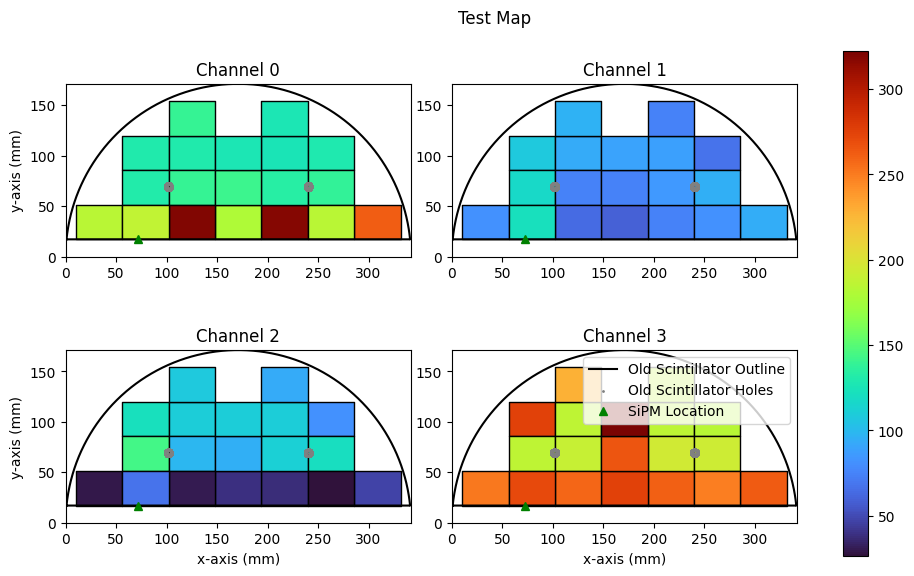

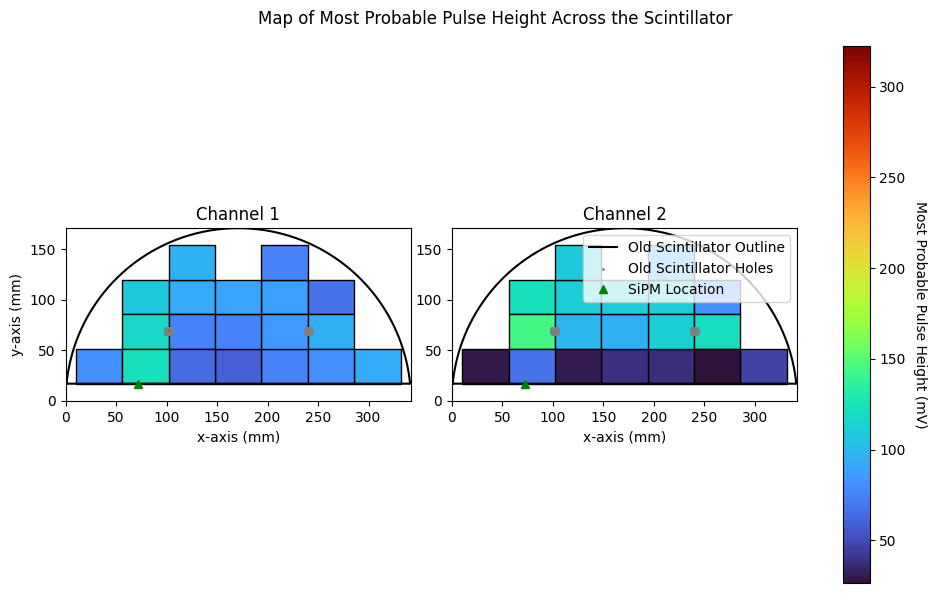

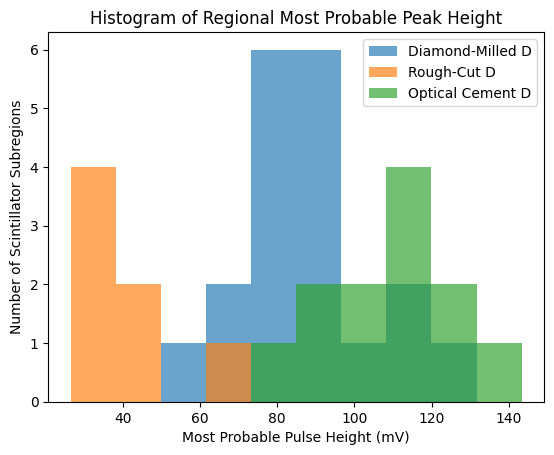

26.51589648234563 322.3981375347605


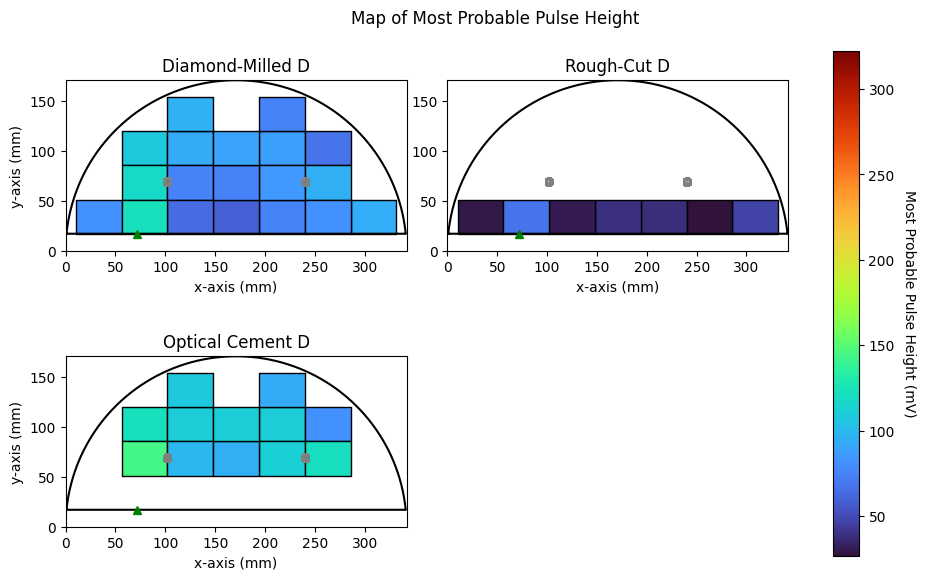

In [189]:

make_rough_colour_map(ph_mpv_list,old_box_data, [0,1,2,3], 'Test Map')
make_rough_colour_map(ph_mpv_list,old_box_data, [1,2], 'Map of Most Probable Pulse Height Across the Scintillator','Most Probable Pulse Height (mV)')

make_regional_hist(ph_mpv_list,'Histogram of Regional Most Probable Peak Height','Most Probable Pulse Height (mV)')
make_clean_colour_map(ph_mpv_list,old_box_data,title='Map of Most Probable Pulse Height',cmap_label='Most Probable Pulse Height (mV)')

### Detector Efficiency

Detector efficiency calculation method 1:\
Compare event rate of channels 0 and 3 to channels 1 and 2

Channel 1 has efficiency of 99.5065
Channel 2 has efficiency of 99.6797
The average detector of the bottom row (diamond-milled) is 0.993706485849203
The average detector of the bottom row (rough_cut) is 0.9937380964046764
The average detector of all other locations (diamond-milled) is 0.9959169126840631
The average detector of all other locations (optical cement) is 0.9977102909115868


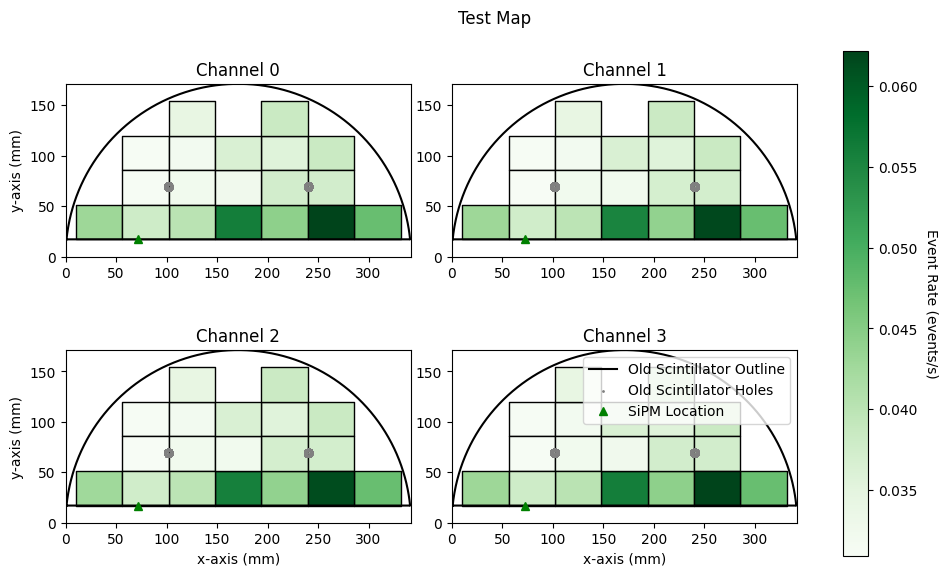

0.03089361687179588 0.06220130967402154


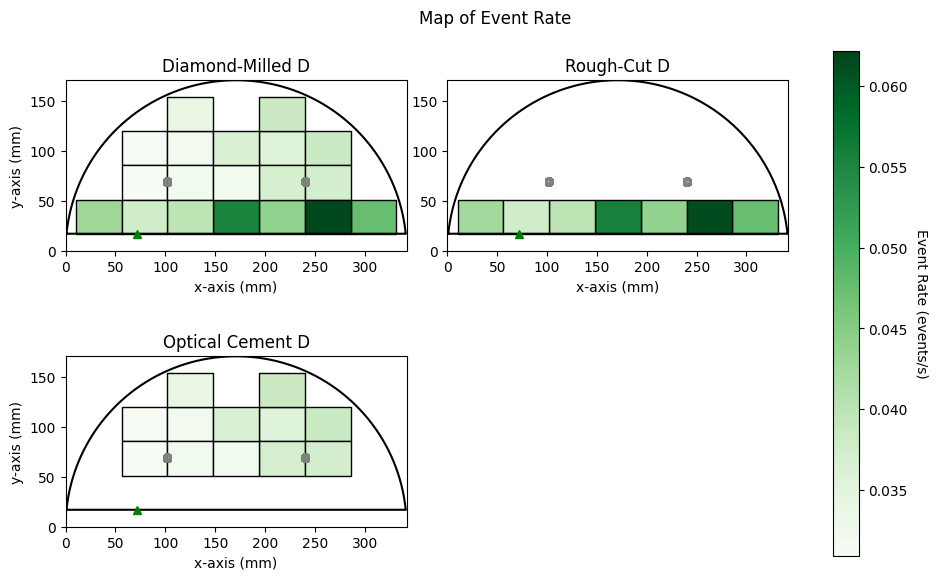

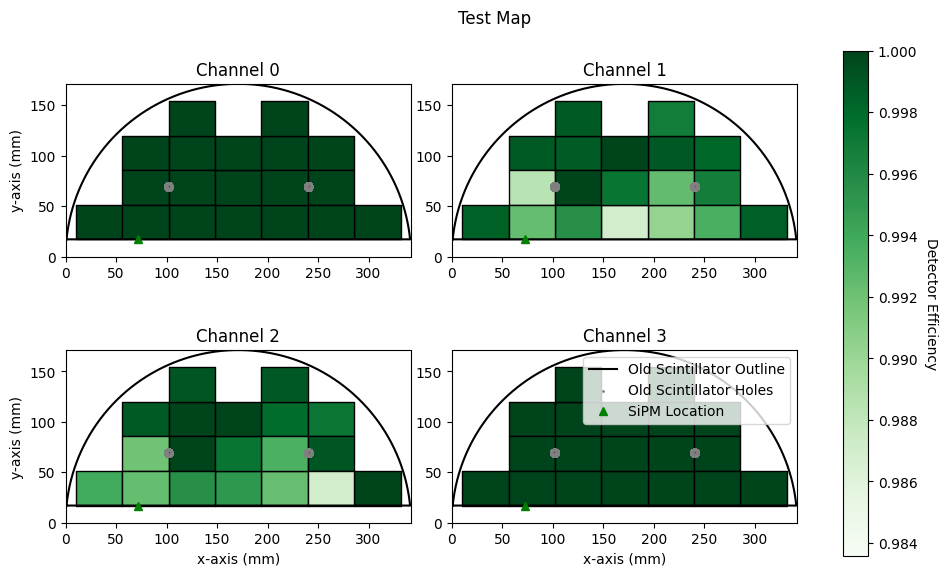

0.987025023169602 1


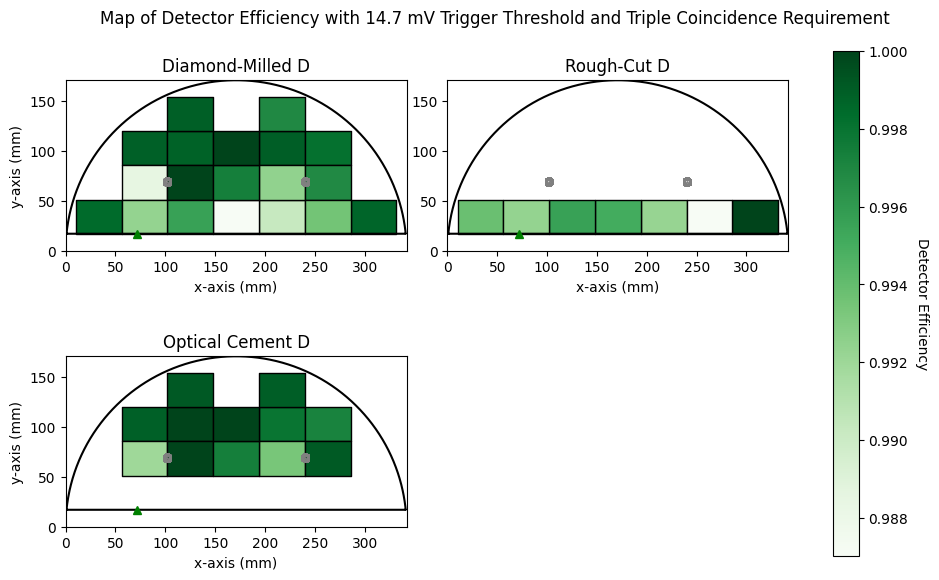

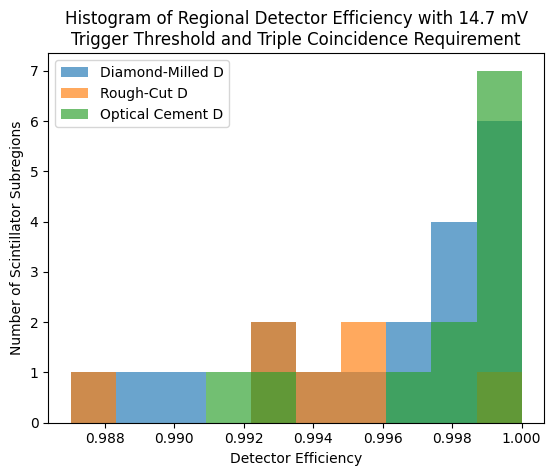

In [190]:
duration_dict,max_e_dict = {},{}
for key in data_dict.keys():
   if key == 'baseline': continue
   test = data_dict[key][3]
   duration, e = test.duration, test.NEvents
   duration_dict[key] = duration
   # print(f"Weighting for {int(test.id)}: {old_box_data[int(test.id)]['weighting']*100:.2f}%")
   max_e_dict[key] = e*old_box_data[int(test.id)]['weighting'] if int(test.id) < 60 else e
   # if int(key) < 7: max_e_dict[key] *= 0.9562 # Reweighting of bottom row


de_list,e_list,er_list = [],[],[]
for ch in range(n_chs):
   de_dict,e_dict,er_dict = {},{},{}
   total_e,total_max_e = 0,0
   for key in data_dict.keys():
      if key != 'baseline':
         test = data_dict[key][ch]
         duration,max_e = duration_dict[key],max_e_dict[key]
         e = test.NEvents
         total_e += e
         total_max_e += max_e
         er = e/duration
         # print(f"Event Rate: {er}")
         # print(f"max_er: {max_er}")
         de = e/max_e
         # if ch in [1,2]: print(f'Channel {ch}: {round(e)} events seen out of {max_e} total ({de*100:.2f}%)')
         # print(f"Detector Efficiency: {de}")
         de_dict[int(key)] = de
         e_dict[int(key)] = e
         er_dict[int(key)] = er
   de_list.append(de_dict)
   e_list.append(e_dict)
   er_list.append(er_dict)
   if ch in [1,2]: print(f'Channel {ch} has efficiency of {total_e/total_max_e*100:.4f}')

r1_dm, r1_rc = [val for k, val in de_list[1].items() if k<7],[val for k, val in de_list[2].items() if k<7]
rest_dm, rest_oc = [val for k, val in de_list[1].items() if k>=7],[val for k, val in de_list[2].items() if k>=7]
print(f'The average detector of the bottom row (diamond-milled) is {np.mean(r1_dm)}')
print(f'The average detector of the bottom row (rough_cut) is {np.mean(r1_rc)}')
print(f'The average detector of all other locations (diamond-milled) is {np.mean(rest_dm)}')
print(f'The average detector of all other locations (optical cement) is {np.mean(rest_oc)}')

make_rough_colour_map(er_list,old_box_data, [0,1,2,3], 'Test Map', 'Event Rate (events/s)', cmap = 'Greens')
make_clean_colour_map(er_list,old_box_data,title='Map of Event Rate',cmap_label='Event Rate (events/s)',cmap='Greens')
make_rough_colour_map(de_list,old_box_data, [0,1,2,3], 'Test Map', 'Detector Efficiency', cmap = 'Greens')
make_clean_colour_map(de_list,old_box_data,title='Map of Detector Efficiency with 14.7 mV Trigger Threshold and Triple Coincidence Requirement',cmap_label='Detector Efficiency',cmap='Greens',vmax_override=1)

make_regional_hist(de_list,'Histogram of Regional Detector Efficiency with 14.7 mV\nTrigger Threshold and Triple Coincidence Requirement','Detector Efficiency')

In [191]:
print(width)
print(height)
for err in range(1,5):
   err/=2
   print(f'\nIf we were off by {err} mm, we would see {100-err/height*100:.2f}% efficiency (scale up by {height/(height-err):.2f}x)')

print(f'\n\nEach -0.5 mm is a roughly -{0.5/height*100:.2f}% detector efficiency error')

print(f'{99.33/99.64} = 1 - x/{height}')
print(f'{(1-99.33/99.64)*height} mm')

45.92
34.28

If we were off by 0.5 mm, we would see 98.54% efficiency (scale up by 1.01x)

If we were off by 1.0 mm, we would see 97.08% efficiency (scale up by 1.03x)

If we were off by 1.5 mm, we would see 95.62% efficiency (scale up by 1.05x)

If we were off by 2.0 mm, we would see 94.17% efficiency (scale up by 1.06x)


Each -0.5 mm is a roughly -1.46% detector efficiency error
0.9968887996788438 = 1 - x/34.28
0.10665194700923432 mm


### Energy Peak

In [192]:
K_list, mu_list, sigma_list = [],[],[]
for ch in range(n_chs):
   K_dict, mu_dict, sigma_dict = {},{},{}
   if ch in [1,2]:
      for key in data_dict.keys():
         if key != 'baseline':
            test = data_dict[key][ch]
            K,mu,sigma = test.get_EMG_params(plot=False)
            K_dict[int(key)] = K
            mu_dict[int(key)] = mu
            sigma_dict[int(key)] = sigma
   K_list.append(K_dict)
   mu_list.append(mu_dict)
   sigma_list.append(sigma_dict)

1.5952394185959242 15.472264540647574


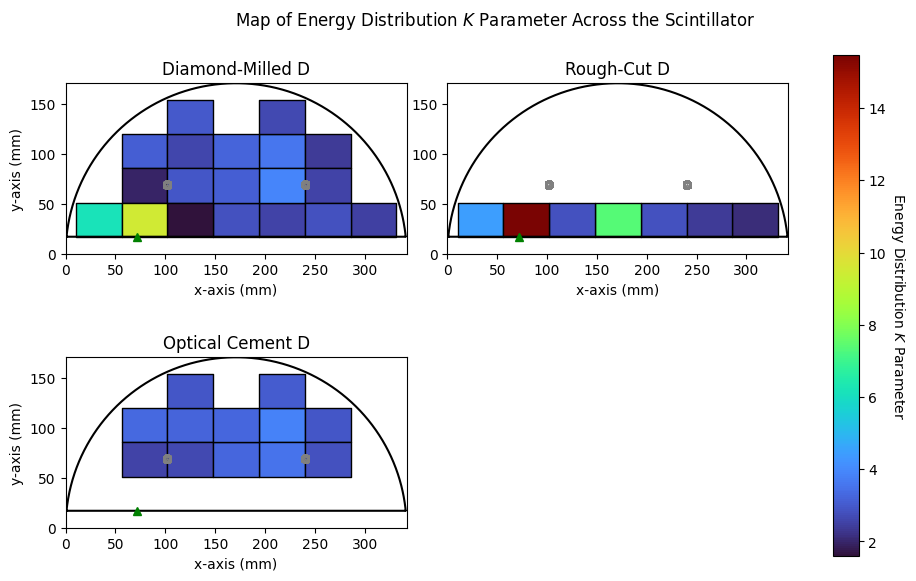

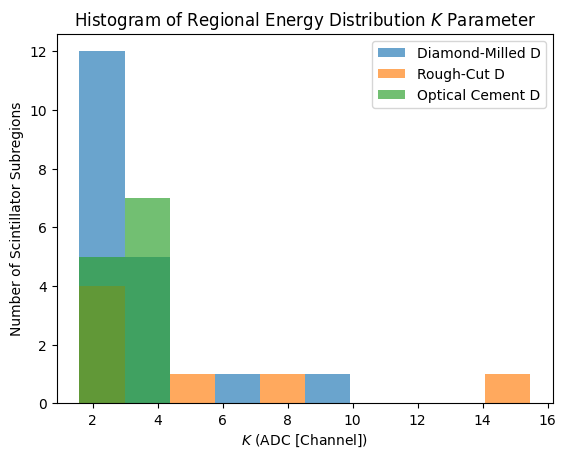

322.6986893569734 1459.0195431950108


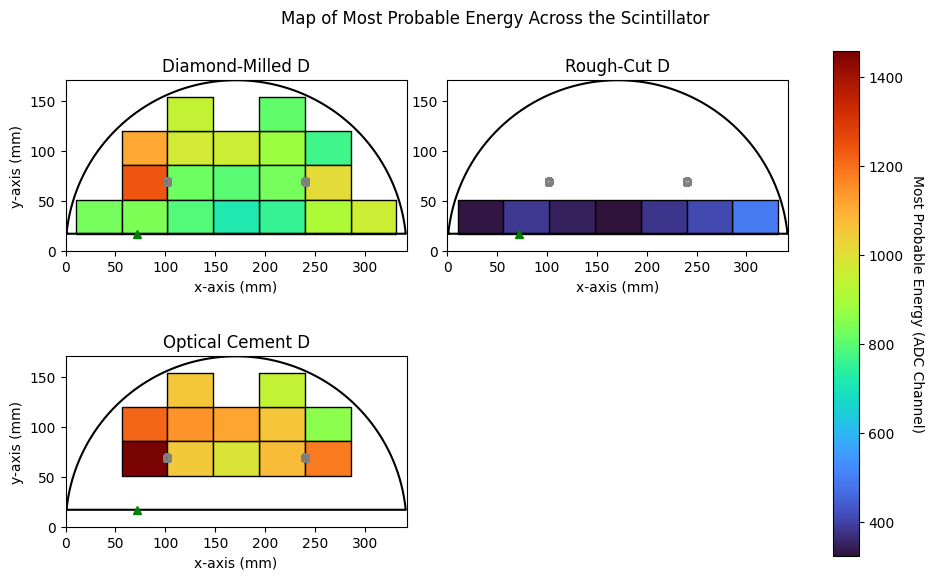

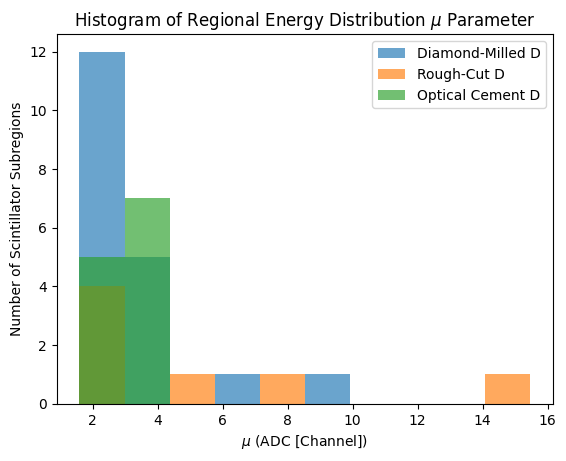

44.204122663186 199.5833693934934


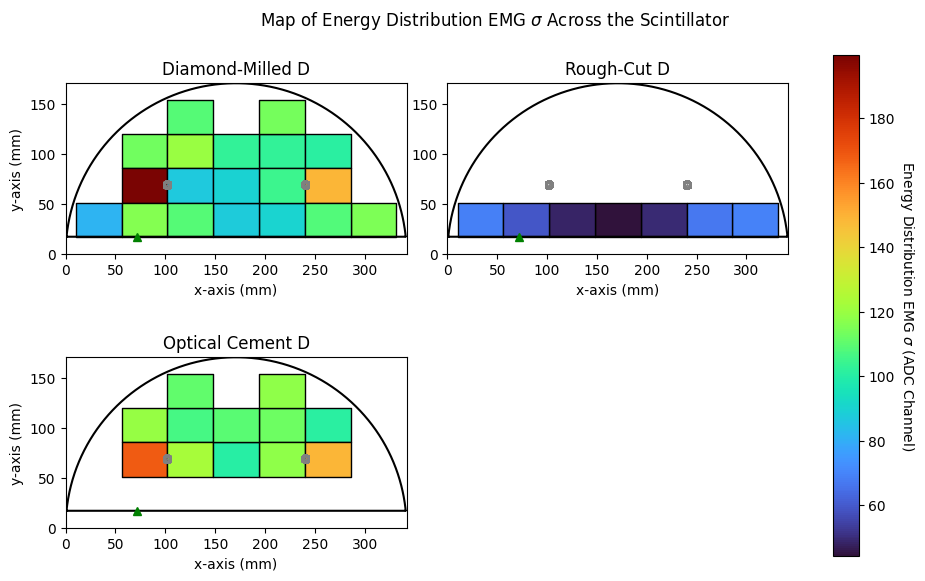

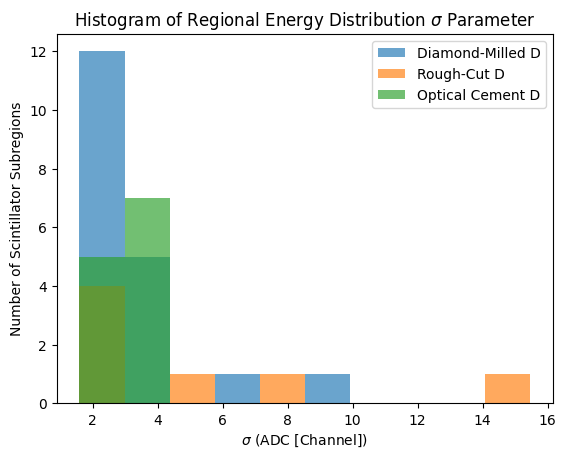

In [193]:
make_clean_colour_map(K_list,old_box_data, title='Map of Energy Distribution $K$ Parameter Across the Scintillator',cmap_label='Energy Distribution $K$ Parameter ')

make_regional_hist(K_list,'Histogram of Regional Energy Distribution $K$ Parameter', '$K$ (ADC [Channel])')

make_clean_colour_map(mu_list,old_box_data, title='Map of Most Probable Energy Across the Scintillator',cmap_label='Most Probable Energy (ADC Channel)')

make_regional_hist(K_list,r'Histogram of Regional Energy Distribution $\mu$ Parameter', r'$\mu$ (ADC [Channel])')

make_clean_colour_map(sigma_list,old_box_data, title=r'Map of Energy Distribution EMG $\sigma$ Across the Scintillator',cmap_label=r'Energy Distribution EMG $\sigma$ (ADC Channel)')

make_regional_hist(K_list,r'Histogram of Regional Energy Distribution $\sigma$ Parameter', r'$\sigma$ (ADC [Channel])')

### Timing Resolution

Idea taken from Sec 4.3 of Efficiency and timing resolution of scintillator tiles read out with silicon photomultipliers by Pooth et al. (2016). By fitting the time difference between two channels to a Gaussian, we can extract the average time difference and spread in time differences. Comparing this to two references (outer and inner scintillators) then allows us to do a little math to get the timing resolution. The width in times, $\sigma_t$ is given as
\begin{equation}
    \sigma_t = \sqrt{\sigma_{t,\mathrm{Det}}^2 - \sigma_{t,\mathrm{Ref}}^2}
\end{equation}
Thus, 
\begin{equation}
    \sigma_1 = \sqrt{\sigma_{t,\mathrm{Ref_1}}^2 - \sigma_{t,\mathrm{Ref_2}}^2}
\end{equation}

\begin{equation}
    \sigma_2 = \sqrt{\sigma_{t,\mathrm{Det}}^2 - \sigma_{t,\mathrm{Ref_1}}^2}
\end{equation}

\begin{equation}
    \sigma_3 = \sqrt{\sigma_{t,\mathrm{Det}}^2 - \sigma_{t,\mathrm{Ref_2}}^2}
\end{equation}
Combining these equations,
\begin{equation}
    \sigma_\mathrm{Det} = \sqrt{\frac{1}{2}(\sigma_1^2 + \sigma_2^2 + \sigma_3^2)}
\end{equation}
If there is an issue with the timing of Channel 0, we can just do channel 1 to channel 2 instead. This might be a nice idea for verification anyways.

{'4': [<detector_region.DetectorRegion object at 0x309880190>, <detector_region.DetectorRegion object at 0x3098800f0>, <detector_region.DetectorRegion object at 0x309880050>, <detector_region.DetectorRegion object at 0x3093300f0>], '13': [<detector_region.DetectorRegion object at 0x30921f750>, <detector_region.DetectorRegion object at 0x30921f7f0>, <detector_region.DetectorRegion object at 0x30921f890>, <detector_region.DetectorRegion object at 0x308dd5130>], '14': [<detector_region.DetectorRegion object at 0x156ed9630>, <detector_region.DetectorRegion object at 0x156ed96d0>, <detector_region.DetectorRegion object at 0x156ed9770>, <detector_region.DetectorRegion object at 0x307943bb0>], '1': [<detector_region.DetectorRegion object at 0x30792f390>, <detector_region.DetectorRegion object at 0x30792f430>, <detector_region.DetectorRegion object at 0x30792f4d0>, <detector_region.DetectorRegion object at 0x307768550>], '15': [<detector_region.DetectorRegion object at 0x30751d8b0>, <detector_

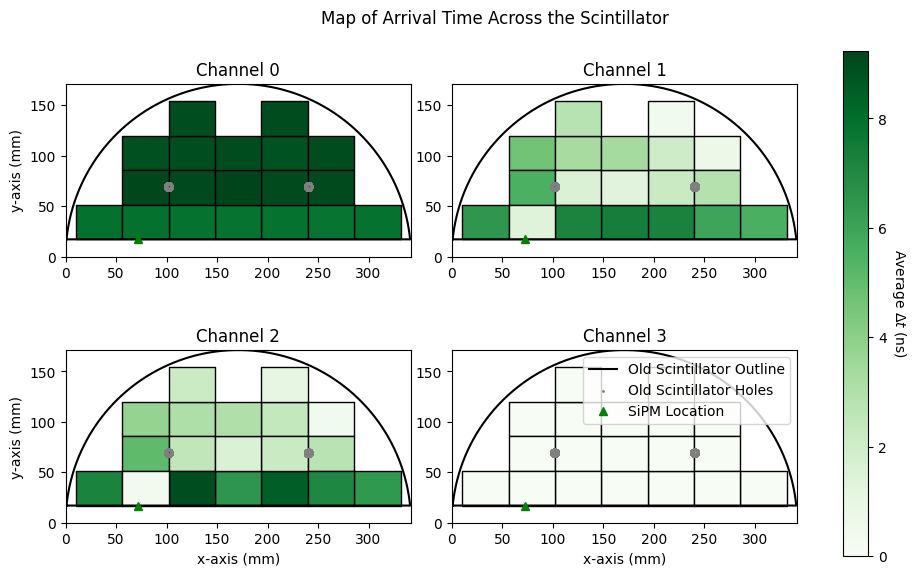

0 9.240083674784168


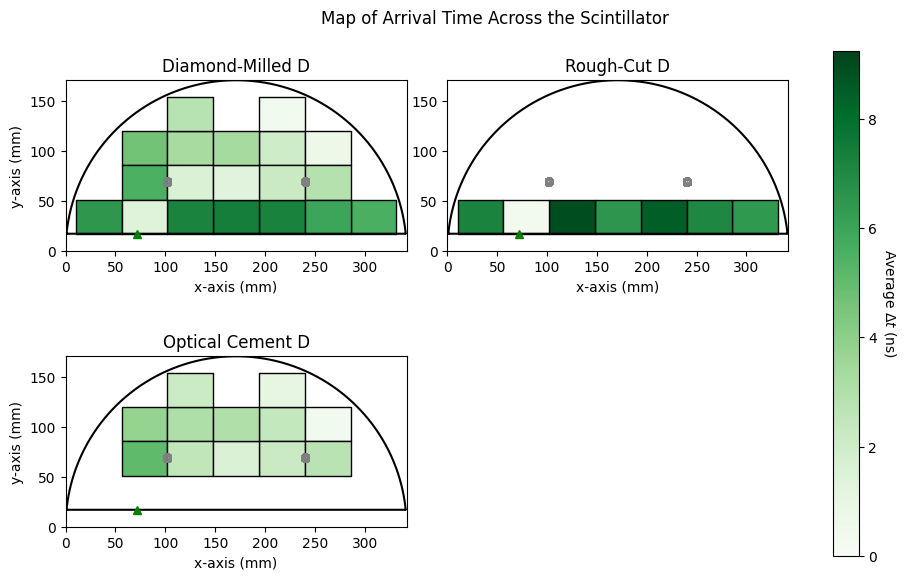

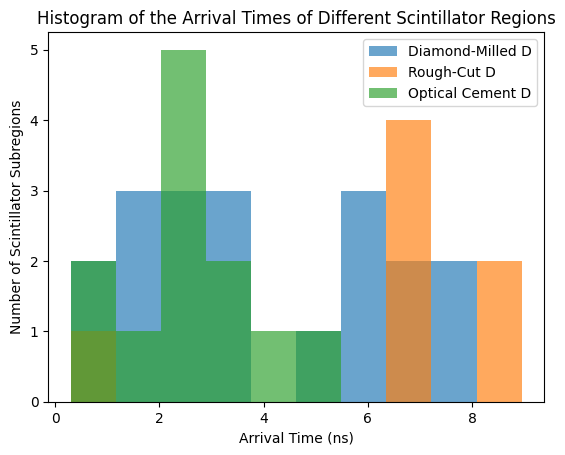

In [194]:
def compare_timing(ref_i,d_dict,display=False):
   ref_t_dict = {}
   for key in d_dict.keys():
      print(d_dict[key])
      test = d_dict[key][ref_i]
      t = test.nmt
      ref_t_dict[key] = t

   mu_t_list,sigma_t_list = [],[]
   for ch in range(n_chs):
      if display: print(f"Channel {ch}")
      mu_t_dict,sigma_t_dict = {},{}
      for key in d_dict.keys():
         if key == 'baseline':
            continue
         if ch == ref_i:
            mu_t_dict[int(key)] = 0
            sigma_t_dict[int(key)] = 0
            if display: print(f"{key} - μ: {0.0} ns, σ: {0.0} ns")
         else:
            test = d_dict[key][ch]
            ref_t = ref_t_dict[key]
            mu, sigma = test.get_dt_params(ref_t,plot=False) if not display else test.get_dt_params(ref_t,plot=True)
            mu_t_dict[int(key)] = np.abs(mu)*1e9 # Convert to ns
            sigma_t_dict[int(key)] = sigma*1e9 # Convert to ns
            if display: print(f"{key} - μ: {mu*1e9:.6f} ns, σ: {sigma*1e9:.6f} ns")
      mu_t_list.append(mu_t_dict)
      sigma_t_list.append(sigma_t_dict)

   return mu_t_list, sigma_t_list

print(data_dict)
mu_0_list,sigma_0_list = compare_timing(0,data_dict)
mu_1_list,sigma_1_list = compare_timing(1,data_dict)
mu_2_list,sigma_2_list = compare_timing(2,data_dict)
mu_3_list,sigma_3_list = compare_timing(3,data_dict)

# make_colour_map(mu_0_list,old_box_data, [0,1,2,3], 'Map of Average Time Difference Between Channel 0 Trigger', r'Average $\Delta t$ (ns)', cmap = 'coolwarm')
# make_colour_map(mu_1_list,old_box_data, [0,1,2,3], 'Map of Average Time Difference Between Channel 1 Trigger', r'Average $\Delta t$ (ns)', cmap = 'coolwarm')
# make_colour_map(mu_2_list,old_box_data, [0,1,2,3], 'Map of Average Time Difference Between Channel 2 Trigger', r'Average $\Delta t$ (ns)', cmap = 'coolwarm')
# make_colour_map(mu_3_list,old_box_data, [0,1,2,3], 'Map of Average Time Difference Between Channel 3 Trigger', r'Average $\Delta t$ (ns)', cmap = 'coolwarm')
# make_colour_map(sigma_3_list,old_box_data, [0,1,2,3], 'Standard Deviation Test Map', r'Standard Deviation of $\Delta t$ (ns)', cmap = 'coolwarm')
make_rough_colour_map(mu_3_list,old_box_data, [0,1,2,3], 'Map of Arrival Time Across the Scintillator', r'Average $\Delta t$ (ns)', cmap = 'Greens')
make_clean_colour_map(mu_3_list,old_box_data, title='Map of Arrival Time Across the Scintillator', cmap_label=r'Average $\Delta t$ (ns)', cmap = 'Greens')

make_regional_hist(mu_3_list,'Histogram of the Arrival Times of Different Scintillator Regions', 'Arrival Time (ns)')

\begin{equation}
    \sigma_{03} = \sqrt{\sigma_{t,\mathrm{~Channel~0}}^2 + \sigma_{t,\mathrm{~Channel~3}}^2}
\end{equation}

\begin{equation}
    \sigma_{10} = \sqrt{\sigma_{t,\mathrm{~Channel~1}}^2 + \sigma_{t,\mathrm{~Channel~0}}^2}
\end{equation}

\begin{equation}
    \sigma_{13} = \sqrt{\sigma_{t,\mathrm{~Channel~1}}^2 + \sigma_{t,\mathrm{~Channel~3}}^2}
\end{equation}

And finally,

\begin{equation}
    \sigma_\mathrm{Channel~1} = \sqrt{\frac{1}{2}(\sigma_{10}^2 + \sigma_{13}^2 - \sigma_{03}^2)}
\end{equation}

\begin{equation}
    \sigma_\mathrm{Channel~2} = \sqrt{\frac{1}{2}(\sigma_{20}^2 + \sigma_{23}^2 - \sigma_{03}^2)}
\end{equation}

1.0056541874420484 5.750499949306169


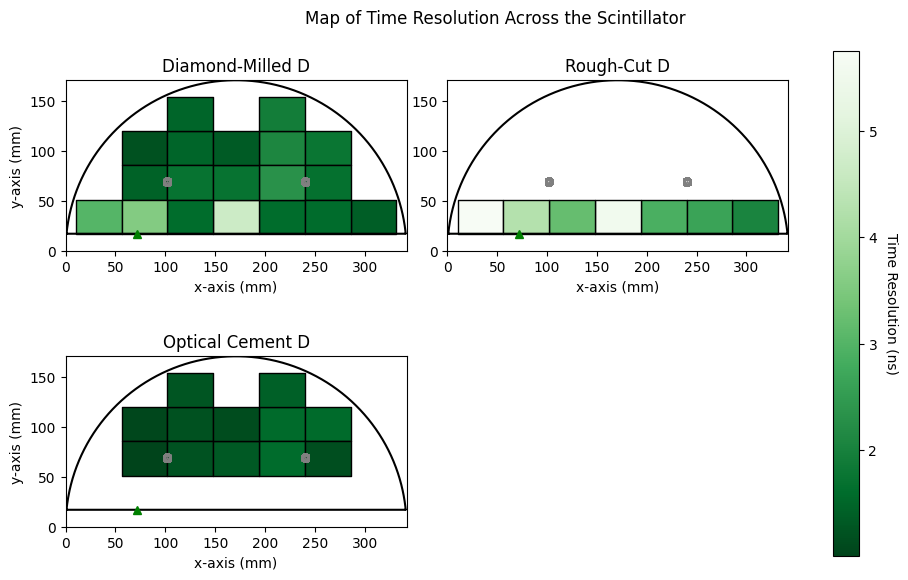

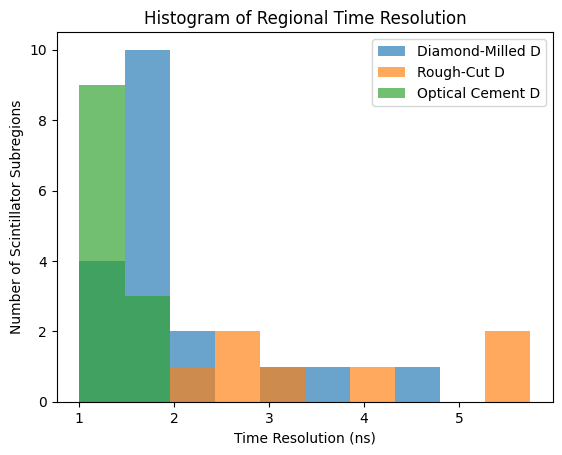

In [195]:
sig1,sig2 = {},{}
for key in data_dict.keys():
   if key == 'baseline':
      continue
   key = int(key)
   sig03 = sigma_3_list[0][key]
   sig10 = sigma_0_list[1][key]
   sig20 = sigma_0_list[2][key]
   sig13 = sigma_3_list[1][key]
   sig23 = sigma_3_list[2][key]
   # print(sig10,sig13,sig03)
   sig1[int(key)] = np.sqrt(0.5*(sig10**2+sig13**2-sig03**2))
   sig2[int(key)] = np.sqrt(0.5*(sig20**2+sig23**2-sig03**2))
time_res_list = [{},sig1,sig2,{}]

make_clean_colour_map(time_res_list,old_box_data, title='Map of Time Resolution Across the Scintillator', cmap_label='Time Resolution (ns)', cmap = 'Greens_r')
make_regional_hist(time_res_list,'Histogram of Regional Time Resolution', 'Time Resolution (ns)')

### Other Plot Making

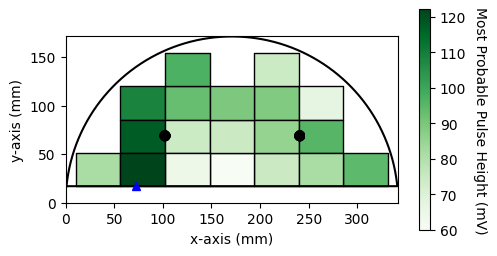

In [196]:
plt.figure(figsize=(5,2.5))

# plt.title('Most Probable Pulse Height')
plt.xlabel('x-axis (mm)')
plt.ylabel('y-axis (mm)')
box_values = ph_mpv_list[1]

box_positions = {}
for key in box_values.keys():
   if key in range(len(old_box_data)):
      corner = old_box_data[key]['xy']
      box_positions[key] = (float(corner[0]),float(corner[1]))

patch_list = []
values = []
for box_id, (x, y) in box_positions.items():
   if box_id in box_values:
      # Create a rectangle patch for the box
      rect = Rectangle((x, y), width, height)
      patch_list.append(rect)
      values.append(box_values[box_id])

p_collection = PatchCollection(patch_list, cmap='Greens', edgecolor='black', linewidth=1)
p_collection.set_array(np.array(values))
ax = plt.gca()
ax.add_collection(p_collection)

plt.plot(old_scint[0], old_scint[1], color='black')
plt.scatter(holes[0], holes[1], s=2, color='black')
plt.plot(SiPM_loc[0],SiPM_loc[1],color='blue',linestyle='',marker='^')
plt.xlim(0,342)
plt.ylim(0,171)
ax.set_aspect('equal')

plt.tight_layout()
cbar = plt.colorbar(p_collection, ax=ax, shrink=1.25)
cbar.set_label('Most Probable Pulse Height (mV)', rotation=270, labelpad=15)
# plt.legend()
plt.show()

'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 'copper', 'copper_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_grey', 'gist_grey_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 'gist_yerg', 'gist_yerg_r', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'grey', 'grey_r', 'hot', 'hot_r', 'hsv', 'hsv_r', 'inferno', 'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'managua', 'managua_r', 'nipy_spectral', 'nipy_spectral_r', 'ocean', 'ocean_r', 'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 'rainbow_r', 'seismic', 'seismic_r', 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r', 'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 'terrain', 'terrain_r', 'turbo', 'turbo_r', 'twilight', 'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'vanimo', 'vanimo_r', 'viridis', 'viridis_r', 'winter', 'winter_r'

In [197]:
def error_estimate(chs, start,stop,lst_of_vals,dtype):
   start+=60
   stop+=60
   print(f"\n--- ERROR ESTIMATE ({dtype}) ---")
   for ch in chs:
      lst_6x = []
      for xx in range(start,stop):
         # print(lst_of_vals[ch].keys())
         lst_6x.append(lst_of_vals[ch][xx])
      # print(lst_6x)
      print(f'Channel {ch}: Mean - {np.mean(lst_6x):.4f}, Std - {np.std(lst_6x):.4f}   ({np.std(lst_6x)/np.mean(lst_6x)*100:.2f}%)')


error_estimate([0,1,2,3],0,3,ph_mpv_list,'Pulse Height')
error_estimate([1,2],0,3,time_res_list,'Time Resolution')
error_estimate([0,1,2,3],0,3,de_list,'Detector Efficiency')


--- ERROR ESTIMATE (Pulse Height) ---
Channel 0: Mean - 151.2768, Std - 29.9584   (19.80%)
Channel 1: Mean - 65.7623, Std - 8.2727   (12.58%)
Channel 2: Mean - 66.0298, Std - 25.9696   (39.33%)
Channel 3: Mean - 282.5223, Std - 21.9943   (7.78%)

--- ERROR ESTIMATE (Time Resolution) ---
Channel 1: Mean - 1.9599, Std - 0.3314   (16.91%)
Channel 2: Mean - 1.9304, Std - 0.8874   (45.97%)

--- ERROR ESTIMATE (Detector Efficiency) ---
Channel 0: Mean - 1.0000, Std - 0.0000   (0.00%)
Channel 1: Mean - 0.9910, Std - 0.0068   (0.69%)
Channel 2: Mean - 0.9972, Std - 0.0027   (0.27%)
Channel 3: Mean - 1.0000, Std - 0.0000   (0.00%)
